In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import scipy.stats as stats
import scipy.spatial as spatial
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pyicon as pyic
import shapely as shp
import shapely.geometry as shpg

import os

import func_process as fprcs
import func_plotting as fplt

----Start loading pyicon.
Loading default parameters from /work/mh1421/m301166/tools/pyicon/pyicon/params_default.json.
----Start loading pyicon.
----Pyicon was loaded successfully.
----Pyicon was loaded successfully.


In [3]:
fpath_tgrid = {}
fpath_ckdtree = {}
fpath_tgrid["atm"] = (
    "/work/mh1421/m301166/tools/pyicon_data/grids/r2b5_atm_r0030/r2b5_atm_r0030_tgrid.nc"
)
fpath_ckdtree["atm"] = (
    "/work/mh1421/m301166/tools/pyicon_data/grids/r2b5_atm_r0030/ckdtree/rectgrids/r2b5_atm_r0030_res0.30_180W-180E_90S-90N.nc"
)
fpath_tgrid["ocn"] = (
    "/work/mh1421/m301166/tools/pyicon_data/grids/r2b7_oce_r0005/r2b7_oce_r0005_tgrid.nc"
)
fpath_ckdtree["ocn"] = (
    "/work/mh1421/m301166/tools/pyicon_data/grids/r2b7_oce_r0005/ckdtree/rectgrids/r2b7_oce_r0005_res0.30_180W-180E_90S-90N.nc"
)

# North Atlantic Mask

In [ ]:
data = 0
data[mask] = 1

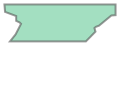

In [4]:
na_shape_path = "/home/m/m301166/projects/CloudLocking/others/mask_shape/north_atlantic_shape.txt"

na_shape = shpg.Polygon(np.loadtxt(na_shape_path, delimiter=","))
na_shape = shp.clip_by_rect(na_shape, xmin=-82, ymin=25, xmax=30, ymax=80)
na_shape_subpolar = shp.clip_by_rect(na_shape, xmin=-82, ymin=43, xmax=30, ymax=80)
# na_shape
na_shape_subpolar

In [5]:
# Read in an atmospheric mask
ds_atm_path = "/work/mh1421/m301166/cloudlocking/icon_mpim_write/build_hdext_write/experiments/cldlock_write_2032/extpar_icon_grid_0030_R02B05_G_orig.nc"
ds_atm = xr.open_dataset(ds_atm_path)

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


(<GeoAxes: >,
  <matplotlib.colorbar.Colorbar at 0x7f0f99fe2ba0>])

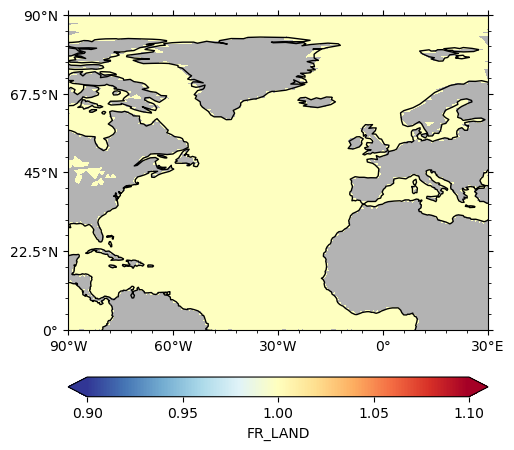

In [6]:
# Create a mask for the North Atlantic region based on the atmospheric dataset
ds_water = xr.where(np.logical_or(ds_atm["FR_LAND"].isnull(), ds_atm["FR_LAND"] < 0.5), 1.0, 0.0)
ds_water.pyic.plot(
    fpath_tgrid=fpath_tgrid["atm"],
    fpath_ckdtree=fpath_ckdtree["atm"],
    land_facecolor="none",
    plot_method="tgrid",
    lon_reg=[-90, 30],
    lat_reg=[0, 90],
)

In [ ]:
# Select region that is within the shape
north_atlantic_mask = ds_water.squeeze().copy().compute()
north_atlantic_subpolar_mask = ds_water.squeeze().copy().compute()
points = np.column_stack(
    (
        north_atlantic_mask.clon.values * 180 / np.pi,
        north_atlantic_mask.clat.values * 180 / np.pi,
    )
)

for i, (lon, lat) in enumerate(points):
    point = shpg.Point(lon, lat)
    if not na_shape.contains(point):
        north_atlantic_mask[i] = 0.0
    else:
        # print(f"Point {i} is within the shape.")
        north_atlantic_mask[i] = ds_water[i].values
    if not na_shape_subpolar.contains(point):
        north_atlantic_subpolar_mask[i] = 0.0
    else:
        north_atlantic_subpolar_mask[i] = ds_water[i].values

In [10]:
# Read Cloud fraction data
cld_dir = "/work/mh1421/m301166/cloudlocking/icon_data/basic_stats/atm_2d_hrz_year_mean.nc"
ds_cld = xr.open_dataset(cld_dir, decode_times=xr.coders.CFDatetimeCoder(use_cftime=True))["clct"].squeeze()

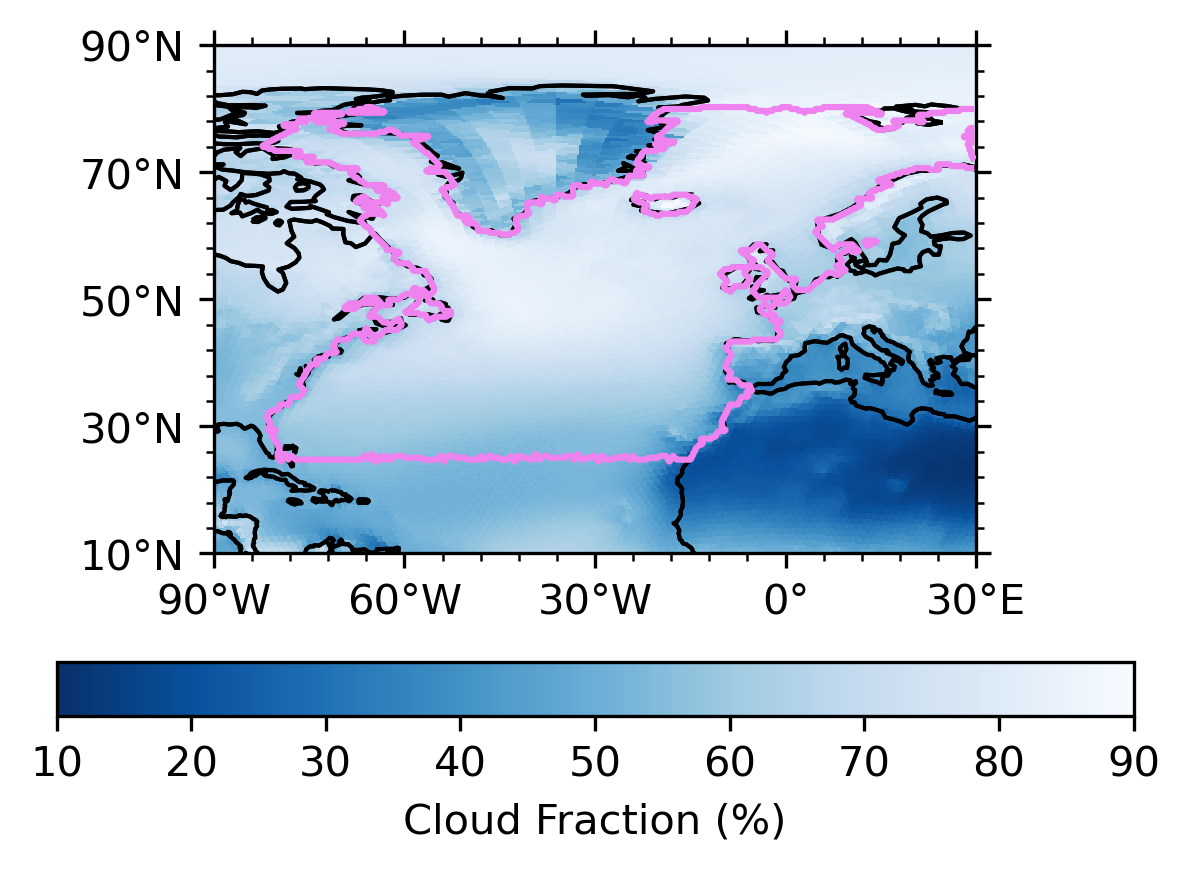

In [45]:
fig, ax = plt.subplots(figsize=(4, 3), dpi=300, subplot_kw={"projection": ccrs.PlateCarree()})

ax, hm = ds_cld.pyic.plot(
    ax=ax,
    cax=0,
    fpath_tgrid=fpath_tgrid["atm"],
    fpath_ckdtree=fpath_ckdtree["atm"],
    land_facecolor="none",
    # plot_method="tgrid",
    lon_reg=[-90, 30],
    lat_reg=[10, 90],
    cmap="Blues_r",
    title_right="",
    clim=[10,90]
)

ax, ct = (north_atlantic_mask + 1).pyic.plot(
    ax=ax,
    cax=0,
    fpath_tgrid=fpath_tgrid["atm"],
    fpath_ckdtree=fpath_ckdtree["atm"],
    land_facecolor="none",
    # plot_method="tgrid",
    use_pcol_or_contf=False,
    conts=[1.5],
    contcolor="violet",
    lon_reg=[-90, 30],
    lat_reg=[10, 90],
    title_right="",
)
cbar = fig.colorbar(hm[0], ax=ax, orientation="horizontal", label="Cloud Fraction (%)")
for line in ct:
    line.set_linewidths(1.5)
    line.set_zorder(5)
fig.tight_layout()
fig.show()

In [10]:
# Add the mask back to the dataset
ds_atm["CLDLOCK_MASK"] = xr.DataArray(north_atlantic_mask.values, dims=north_atlantic_mask.dims, coords=north_atlantic_mask.coords, attrs={
    'standard_name': 'cloud_locking_mask',
    'long_name': 'Regional mask for cloud locking',
    'CDI_grid_type': 'unstructured',
})


In [ ]:
# output_path = ds_atm_path.replace("_orig.nc", ".nc")
# ds_atm.to_netcdf(output_path, mode="w")

In [8]:
ds_atm_subpolar = ds_atm.copy()
ds_atm_subpolar["CLDLOCK_MASK"] = xr.DataArray(north_atlantic_subpolar_mask.values, dims=north_atlantic_subpolar_mask.dims, coords=north_atlantic_subpolar_mask.coords, attrs={
    'standard_name': 'cloud_locking_mask',
    'long_name': 'Regional mask for cloud locking - subpolar North Atlantic',
    'CDI_grid_type': 'unstructured',
})

In [ ]:
# output_path = "/work/mh1421/m301166/cloudlocking/icon_mpim_write/build_hdext_write/experiments/cldlock_write_2032_subpolar/extpar_icon_grid_0030_R02B05_G.nc"
# ds_atm_subpolar.to_netcdf(output_path, mode="w")

# Apply Masks to Atmosphere and Ocean

In [11]:
# First North Atlantic as we already have it
ds_mask_atm = xr.Dataset()
ds_mask_atm["north_atlantic"] = ds_atm["CLDLOCK_MASK"].copy()
ds_mask_atm = ds_mask_atm.rename({"cell": "ncells"})
ds_mask_atm["north_atlantic"].attrs["name"] = "North Atlantic Region"

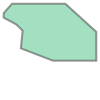

In [26]:
# Then Labrador Sea
labrador_shape_path = (
    "/home/m/m301166/projects/CloudLocking/others/mask_shape/labrador_sea_shape.txt"
)
labrador_shape = shpg.Polygon(np.loadtxt(labrador_shape_path, delimiter=","))
labrador_shape = shp.clip_by_rect(labrador_shape, xmin=-70, ymin=52, xmax=-44, ymax=68)

labrador_shape

In [27]:
ds_mask_atm["labrador_sea"] = ds_mask_atm["north_atlantic"].copy()
for i, (lon, lat) in enumerate(points):
    point = shpg.Point(lon, lat)
    if not labrador_shape.contains(point):
        ds_mask_atm["labrador_sea"][i] = 0.0
    else:
        ds_mask_atm["labrador_sea"][i] = ds_mask_atm["north_atlantic"][i].values
ds_mask_atm["labrador_sea"].attrs["name"] = "Labrador Sea Region"

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


(<GeoAxes: >,
  <matplotlib.colorbar.Colorbar at 0x7f046a9f8b90>])

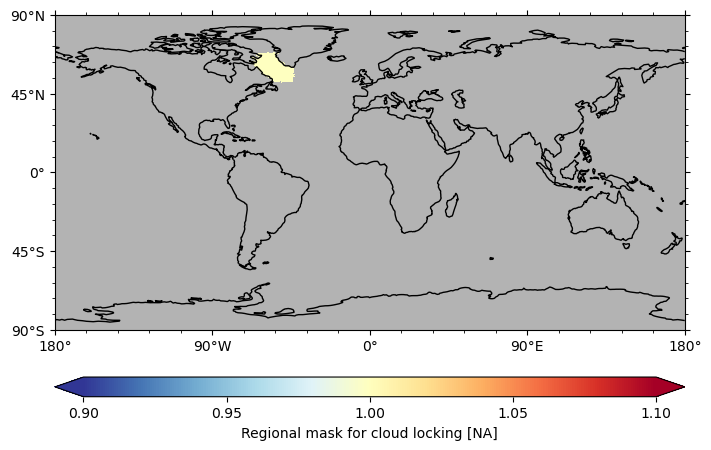

In [12]:
ds_mask_atm["labrador_sea"].pyic.plot(
    fpath_tgrid=fpath_tgrid["atm"],
    fpath_ckdtree=fpath_ckdtree["atm"],
    land_facecolor="none",
    plot_method="tgrid",
)

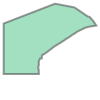

In [28]:
# Then Irminger Sea
irminger_shape_path = (
    "/home/m/m301166/projects/CloudLocking/others/mask_shape/irminger_sea_shape.txt"
)
irminger_shape = shpg.Polygon(np.loadtxt(irminger_shape_path, delimiter=","))
irminger_shape = shp.clip_by_rect(irminger_shape, xmin=-44, ymin=52, xmax=-20, ymax=70)

irminger_shape

In [29]:
ds_mask_atm["irminger_sea"] = ds_mask_atm["north_atlantic"].copy()
for i, (lon, lat) in enumerate(points):
    point = shpg.Point(lon, lat)
    if not irminger_shape.contains(point):
        ds_mask_atm["irminger_sea"][i] = 0.0
    else:
        ds_mask_atm["irminger_sea"][i] = ds_mask_atm["north_atlantic"][i].values
ds_mask_atm["irminger_sea"].attrs["name"] = "Irminger Sea Region"

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


(<GeoAxes: >,
  <matplotlib.colorbar.Colorbar at 0x7f04691c8550>])

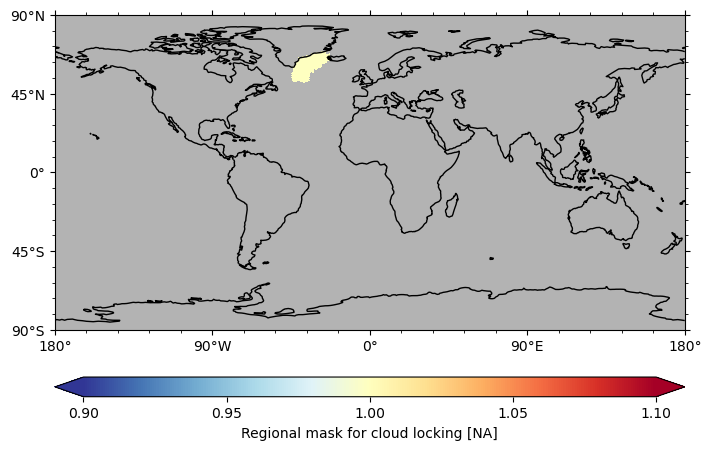

In [15]:
ds_mask_atm["irminger_sea"].pyic.plot(
    fpath_tgrid=fpath_tgrid["atm"],
    fpath_ckdtree=fpath_ckdtree["atm"],
    land_facecolor="none",
    plot_method="tgrid",
)

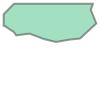

In [30]:
# Then Nordic Sea
nordic_shape_path = (
    "/home/m/m301166/projects/CloudLocking/others/mask_shape/nordic_seas_shape.txt"
)
nordic_shape = shpg.Polygon(np.loadtxt(nordic_shape_path, delimiter=","))
nordic_shape = shp.clip_by_rect(nordic_shape, xmin=-27, ymin=60, xmax=20, ymax=80)
nordic_shape = shp.difference(nordic_shape, irminger_shape)
nordic_shape

In [31]:
ds_mask_atm["nordic_seas"] = ds_mask_atm["north_atlantic"].copy()
for i, (lon, lat) in enumerate(points):
    point = shpg.Point(lon, lat)
    if not nordic_shape.contains(point):
        ds_mask_atm["nordic_seas"][i] = 0.0
    else:
        ds_mask_atm["nordic_seas"][i] = ds_mask_atm["north_atlantic"][i].values
ds_mask_atm["nordic_seas"].attrs["name"] = "Nordic Seas Region"

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


(<GeoAxes: >,
  <matplotlib.colorbar.Colorbar at 0x7f046399fc50>])

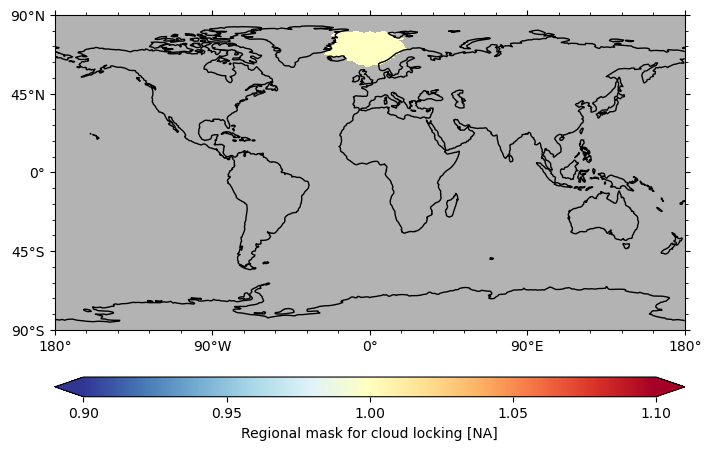

In [18]:
ds_mask_atm["nordic_seas"].pyic.plot(
    fpath_tgrid=fpath_tgrid["atm"],
    fpath_ckdtree=fpath_ckdtree["atm"],
    land_facecolor="none",
    plot_method="tgrid",
)

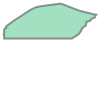

In [32]:
# Then the rest part
rest_shape_path = (
    "/home/m/m301166/projects/CloudLocking/others/mask_shape/rest_subpolar_atlantic_shape.txt"
)
rest_shape = shpg.Polygon(np.loadtxt(rest_shape_path, delimiter=","))
rest_shape = shp.clip_by_rect(rest_shape, xmin=-36, ymin=52, xmax=0, ymax=65)
rest_shape = shp.difference(rest_shape, irminger_shape)
rest_shape

In [33]:
ds_mask_atm["rest_subpolar_atlantic"] = ds_mask_atm["north_atlantic"].copy()
for i, (lon, lat) in enumerate(points):
    point = shpg.Point(lon, lat)
    if not rest_shape.contains(point):
        ds_mask_atm["rest_subpolar_atlantic"][i] = 0.0
    else:
        ds_mask_atm["rest_subpolar_atlantic"][i] = ds_mask_atm["north_atlantic"][i].values
ds_mask_atm["rest_subpolar_atlantic"].attrs["name"] = "Rest Subpolar Atlantic Region"

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


(<GeoAxes: >,
  <matplotlib.colorbar.Colorbar at 0x7f047d98ce10>])

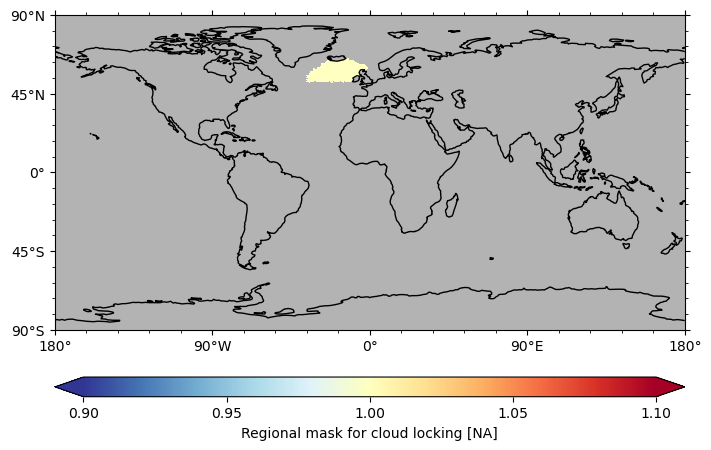

In [21]:
ds_mask_atm["rest_subpolar_atlantic"].pyic.plot(
    fpath_tgrid=fpath_tgrid["atm"],
    fpath_ckdtree=fpath_ckdtree["atm"],
    land_facecolor="none",
    plot_method="tgrid",
)

In [34]:
# add them together to get the overall subpolar atlantic region
ds_mask_atm["subpolar_atlantic"] = ds_mask_atm["labrador_sea"] + ds_mask_atm["irminger_sea"] +ds_mask_atm["nordic_seas"] + ds_mask_atm["rest_subpolar_atlantic"]
ds_mask_atm["subpolar_atlantic"].attrs["name"] = "Subpolar Atlantic Region"

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


(<GeoAxes: >,
  <matplotlib.colorbar.Colorbar at 0x7f04609aa990>])

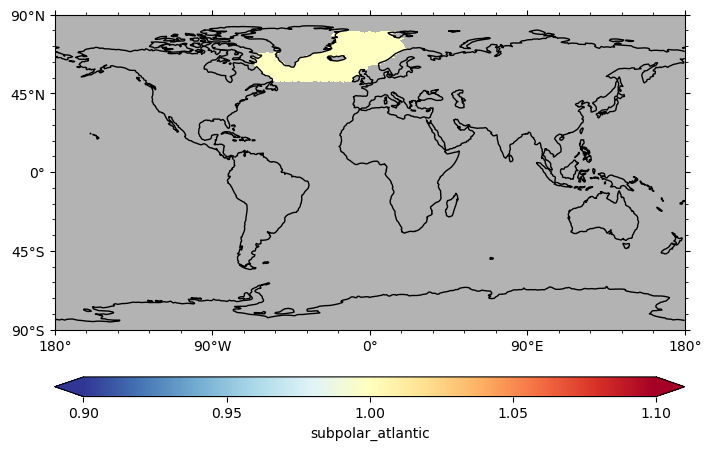

In [23]:
ds_mask_atm["subpolar_atlantic"].pyic.plot(
    fpath_tgrid=fpath_tgrid["atm"],
    fpath_ckdtree=fpath_ckdtree["atm"],
    land_facecolor="none",
    plot_method="tgrid",
)

In [36]:
# Again but for ocean grids
ds_mask_ocn = xr.Dataset()
ocn_grid_sample = xr.open_dataset(fpath_tgrid["ocn"])["cell_area"]
ocn_grid_sample = ocn_grid_sample.rename({"cell": "ncells"})
ocn_points = np.column_stack(
    (
        ocn_grid_sample.clon.values * 180 / np.pi,
        ocn_grid_sample.clat.values * 180 / np.pi,
    )
)

for var, mask in zip(["north_atlantic", "labrador_sea", "irminger_sea", "nordic_seas", "rest_subpolar_atlantic"], [na_shape, labrador_shape, irminger_shape, nordic_shape, rest_shape]):
    print(var)
    ds_mask_ocn[var] = ocn_grid_sample.copy()
    for i, (lon, lat) in enumerate(ocn_points):
        point = shpg.Point(lon, lat)
        if mask.contains(point):
            ds_mask_ocn[var][i] = 1.0
        else:
            ds_mask_ocn[var][i] = 0.0
    ds_mask_ocn[var].attrs = ds_mask_atm[var].attrs

north_atlantic
labrador_sea
irminger_sea
nordic_seas
rest_subpolar_atlantic


In [37]:
ds_mask_ocn["subpolar_atlantic"] = (
    ds_mask_ocn["labrador_sea"]
    + ds_mask_ocn["irminger_sea"]
    + ds_mask_ocn["nordic_seas"]
    + ds_mask_ocn["rest_subpolar_atlantic"]
)
ds_mask_ocn["subpolar_atlantic"].attrs["name"] = "Subpolar Atlantic Region"

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


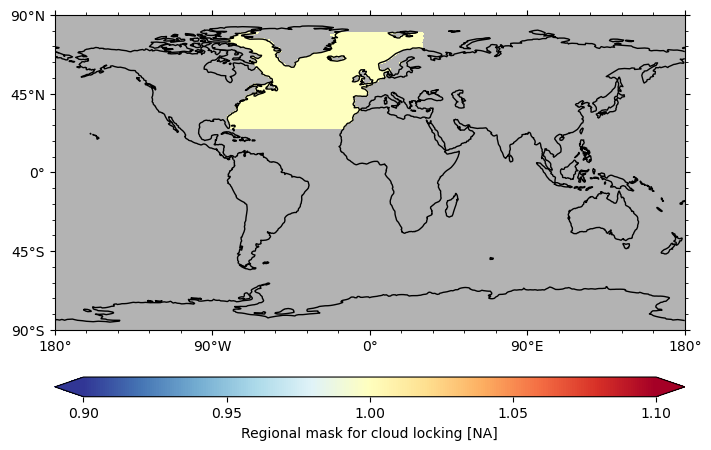

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


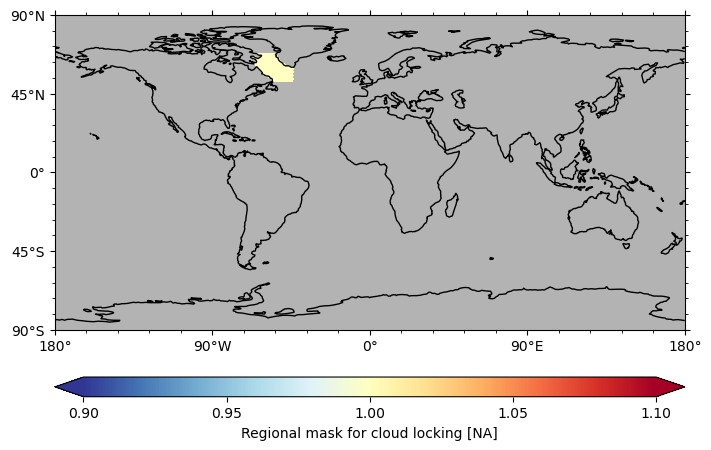

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


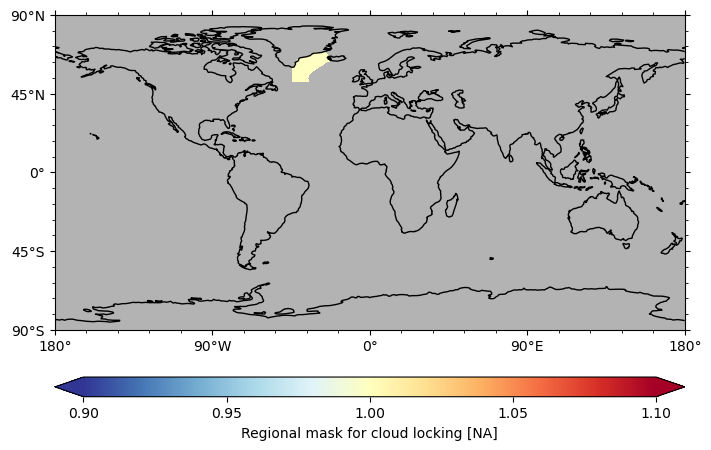

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


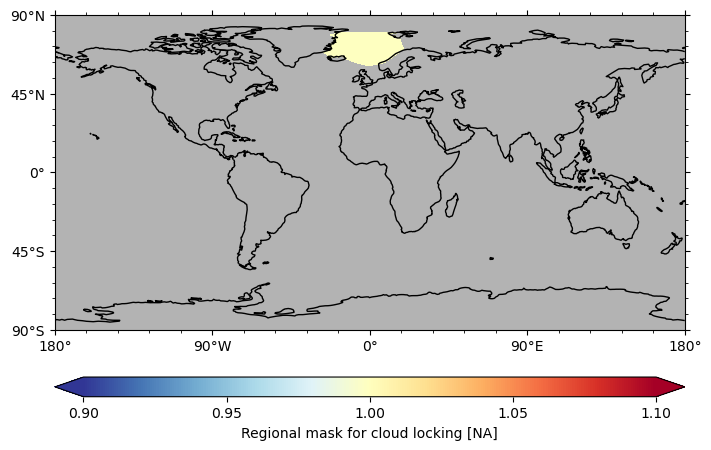

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


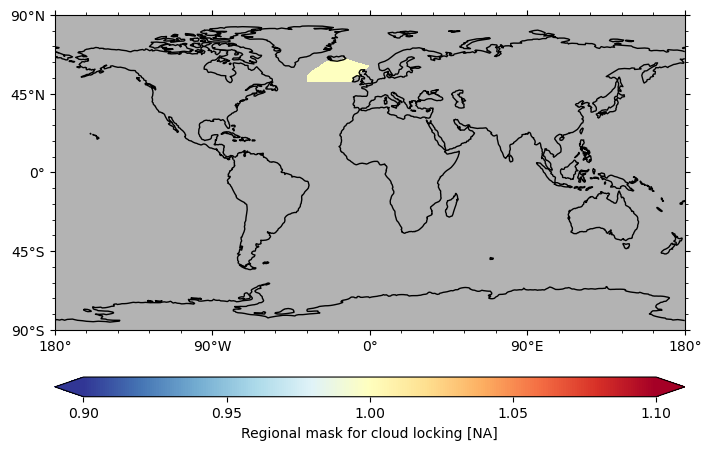

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


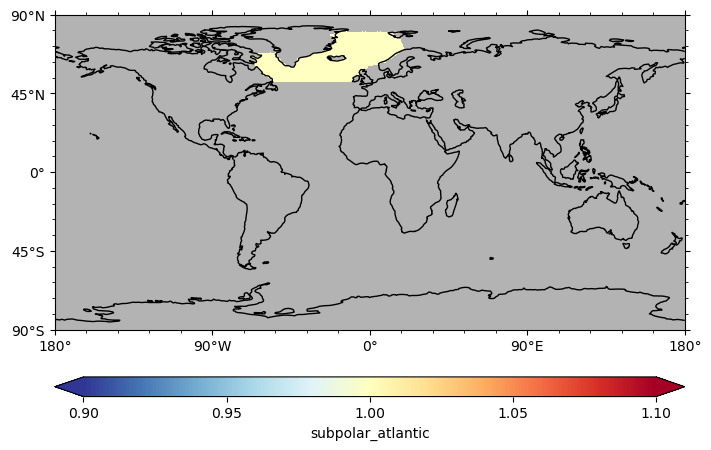

In [69]:
for var in ds_mask_ocn:
    fig, hm = ds_mask_ocn[var].pyic.plot(
        fpath_tgrid=fpath_tgrid["ocn"],
        fpath_ckdtree=fpath_ckdtree["ocn"],
        land_facecolor="none",
        plot_method="tgrid",
    )
    plt.show()

In [38]:
output_dir = "/work/mh1421/m301166/cloudlocking/icon_data/masks"
ds_mask_atm.to_netcdf(f"{output_dir}/subpolar_atlantic_regions_mask_atm.nc")
ds_mask_ocn.to_netcdf(f"{output_dir}/subpolar_atlantic_regions_mask_ocn.nc")

## Small North Atlantic Mask (40-60N)

In [12]:
na_shape_small = shp.clip_by_rect(na_shape, xmin=-82, ymin=40, xmax=30, ymax=60)
da_atm_na_small = ds_mask_atm["north_atlantic"].copy()
for i, (lon, lat) in enumerate(points):
    point = shpg.Point(lon, lat)
    if not na_shape_small.contains(point):
        da_atm_na_small[i] = 0.0
    else:
        da_atm_na_small[i] = ds_mask_atm["north_atlantic"][i].values
da_atm_na_small.attrs["name"] = "North Atlantic Region between 40N and 60N"

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


(<GeoAxes: >,
  <matplotlib.colorbar.Colorbar at 0x7f0f91a0de50>])

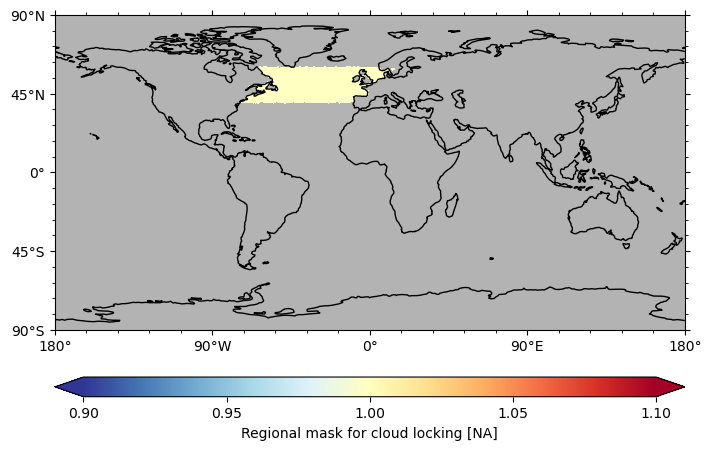

In [13]:
da_atm_na_small.pyic.plot(
    fpath_tgrid=fpath_tgrid["atm"],
    fpath_ckdtree=fpath_ckdtree["atm"],
    land_facecolor="none",
    plot_method="tgrid",
)

In [ ]:
output_dir = "/work/mh1421/m301166/cloudlocking/icon_data/masks"
da_atm_na_small.to_netcdf(f"{output_dir}/north_atlantic_40N_60N_mask_atm.nc")

# Get OSNAP mask

In [39]:
ds_osnap = xr.open_dataset(
    "/home/m/m301166/projects/CloudLocking/others/OSNAP_Gridded_TSV_201408_202006_2023.nc"
)
osnap_points = np.column_stack([ds_osnap["LONGITUDE"].values, ds_osnap["LATITUDE"].values])

In [40]:
# Densify the OSNAP data until the resolution is smaller than 5km

# Define helper functions
def haversine_distance(lonlat1, lonlat2, R=6371.0):
    """
    Calculate the great-circle distance between two points on the Earth's surface.

    Parameters:
    lonlat1, lonlat2: Longitude and latitude coordinates [longitude, latitude] (in degrees)
    R: Earth's radius (default is 6371.0 km)

    Returns:
    Distance (in the same units as R)
    """
    lon1, lat1 = np.radians(lonlat1)
    lon2, lat2 = np.radians(lonlat2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c


def spherical_midpoint(lonlat1, lonlat2):
    """
    Calculate the midpoint between two points on the Earth's surface along the great-circle path.

    Parameters:
    lonlat1, lonlat2: Longitude and latitude coordinates [longitude, latitude] (in degrees)

    Returns:
    Midpoint coordinates [longitude, latitude] (in degrees)
    """
    lon1, lat1 = np.radians(lonlat1)
    lon2, lat2 = np.radians(lonlat2)

    # Convert to Cartesian coordinates
    x1 = np.cos(lat1) * np.cos(lon1)
    y1 = np.cos(lat1) * np.sin(lon1)
    z1 = np.sin(lat1)

    x2 = np.cos(lat2) * np.cos(lon2)
    y2 = np.cos(lat2) * np.sin(lon2)
    z2 = np.sin(lat2)

    # Calculate midpoint vector
    mx = x1 + x2
    my = y1 + y2
    mz = z1 + z2

    # Normalize
    norm = np.sqrt(mx**2 + my**2 + mz**2)
    mx, my, mz = mx / norm, my / norm, mz / norm

    # Convert back to longitude and latitude
    lon_mid = np.arctan2(my, mx)
    lat_mid = np.arcsin(mz)

    return np.degrees([lon_mid, lat_mid])

# Define function to densify data points
def refine_points(c, r, d, R=6371.0):
    """
    Iterate to densify the point cloud until the nearest neighbor distance for each point is less than or equal to r or the maximum number of iterations is reached.

    Parameters:
    c: numpy array, shape (k, 2), [longitude, latitude] (in degrees)
    r: distance threshold (in the same units as R)
    d: maximum number of iterations
    R: Earth's radius (default is 6371.0 km)

    Returns:
    Densified point cloud
    """
    # Check for edge cases
    if len(c) < 2 or r <= 0 or d <= 0:
        return c

    # Create a copy of the point cloud
    points = c.copy()

    # Iterate to densify
    for iteration in range(d):
        # Convert to 3D Cartesian coordinates
        lon_rad = np.radians(points[:, 0])
        lat_rad = np.radians(points[:, 1])

        x = R * np.cos(lat_rad) * np.cos(lon_rad)
        y = R * np.cos(lat_rad) * np.sin(lon_rad)
        z = R * np.sin(lat_rad)
        cartesian = np.column_stack((x, y, z))

        # Build spatial index
        tree = spatial.cKDTree(cartesian)

        # Calculate chord length threshold
        chord_threshold = 2 * R * np.sin(r / (2 * R))

        # Record midpoints to add
        midpoints_to_add = []

        # Check each point
        for i in range(len(points)):
            # Query the nearest 3 points (including itself)
            distances, indices = tree.query(cartesian[i], k=min(3, len(points)))

            # Get the nearest neighbors (excluding itself)
            neighbors = []
            for dist, idx in zip(distances[1:], indices[1:]):
                # Calculate the actual geodesic distance
                actual_dist = haversine_distance(points[i], points[idx], R)
                neighbors.append((actual_dist, idx))

            # Sort by distance
            neighbors.sort(key=lambda x: x[0])

            # Check the nearest two neighbors
            for dist, idx in neighbors[:2]:
                if dist > r:
                    # Add midpoint
                    mid = spherical_midpoint(points[i], points[idx])
                    midpoints_to_add.append(mid)

        # If no points need to be added, terminate early
        if not midpoints_to_add:
            break

        # Add new midpoints
        midpoints_to_add = np.array(midpoints_to_add)

        # Remove duplicates
        if len(midpoints_to_add) > 0:
            # Round to 8 decimal places and remove duplicates
            rounded = np.round(midpoints_to_add, 8)
            _, unique_indices = np.unique(rounded, axis=0, return_index=True)
            unique_midpoints = midpoints_to_add[unique_indices]

            # Add to point cloud
            points = np.vstack([points, unique_midpoints])

    return points

In [41]:
# Densify the OSNAP points
osnap_points_densified = refine_points(osnap_points, r=5, d=5)

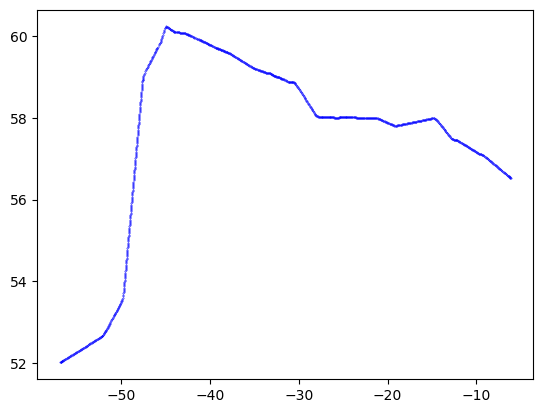

In [42]:
plt.scatter(osnap_points_densified[:, 0], osnap_points_densified[:, 1], s=0.1, c='blue', label='Densified OSNAP Points')

In [43]:
def find_points_within_threshold(a, b, r, R=6371.0):
    """
    Find all points in b whose great-circle distance to any point in a does not exceed the threshold r in km.

    Parameters:
    a : numpy.array, shape (m, 2), [lon, lat] (unit: deg)
    b : numpy.array, shape (n, 2), [lon, lat] (unit: deg)
    r : distance threshold (unit: km)
    R : Earth radius (default 6371.0km)

    Returns:
    mask : boolean array, shape (n,), indicating points in b that meet the criteria
    """
    # Special case handling
    if r <= 0:
        return np.zeros(b.shape[0], dtype=bool)
    if r >= np.pi * R:
        return np.ones(b.shape[0], dtype=bool)

    # Convert to radians
    a_rad = np.deg2rad(a)
    b_rad = np.deg2rad(b)

    # Convert to 3D Cartesian coordinates
    def to_cartesian(lonlat):
        lon, lat = lonlat[:, 0], lonlat[:, 1]
        x = R * np.cos(lat) * np.cos(lon)
        y = R * np.cos(lat) * np.sin(lon)
        z = R * np.sin(lat)
        return np.column_stack((x, y, z))

    a_cart = to_cartesian(a_rad)
    b_cart = to_cartesian(b_rad)

    # Calculate chord length threshold (3D Euclidean distance corresponding to spherical distance threshold)
    chord_threshold = 2 * R * np.sin(r / (2 * R))

    # Build KDTree for a in 3D
    tree = spatial.cKDTree(a_cart)

    # Query the nearest distance from each point in b to a
    dists, _ = tree.query(b_cart, k=1)  # Get the 3D Euclidean distance to the nearest point

    # Convert the 3D Euclidean distance back to spherical distance
    mask = dists <= chord_threshold

    return mask

In [44]:
atm_osnap_ind = find_points_within_threshold(osnap_points_densified, points, r=40.0 * 1.7321)
atm_osnap_points = points[atm_osnap_ind]
ocn_osnap_ind = find_points_within_threshold(osnap_points_densified, ocn_points, r=10.0 * 1.7321)
ocn_osnap_points = ocn_points[ocn_osnap_ind]

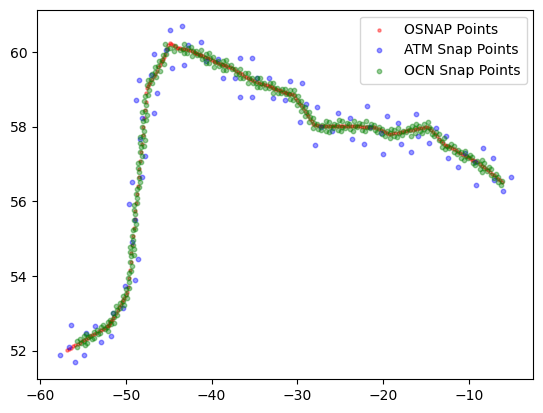

In [45]:
plt.scatter(osnap_points[:, 0], osnap_points[:, 1], c='red', label='OSNAP Points', s = 5, alpha=0.4)
plt.scatter(
    atm_osnap_points[:, 0], atm_osnap_points[:, 1], c="blue", label="ATM Snap Points", s = 10, alpha=0.4
)
plt.scatter(
    ocn_osnap_points[:, 0], ocn_osnap_points[:, 1], c="green", label="OCN Snap Points", s = 10, alpha=0.4
)
plt.legend()

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


(<GeoAxes: >,
  <matplotlib.colorbar.Colorbar at 0x7f045c2f8690>])

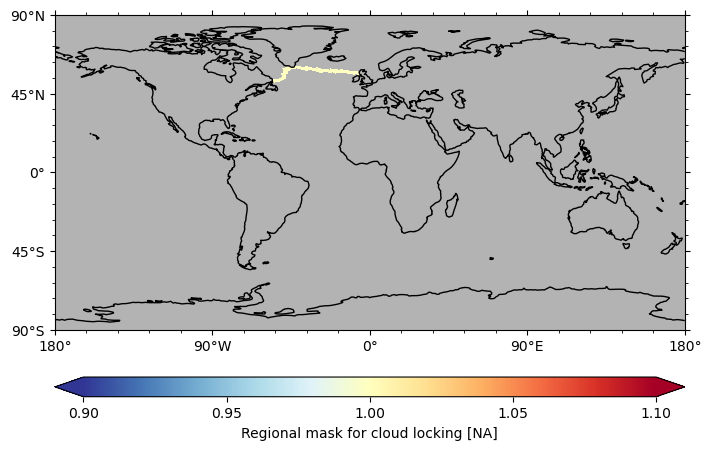

In [46]:
ds_osnap_mask_atm = ds_mask_atm["north_atlantic"].where(atm_osnap_ind)
ds_osnap_mask_atm.attrs["name"] = "Points near OSNAP line"
ds_osnap_mask_atm.pyic.plot(
    fpath_tgrid=fpath_tgrid["atm"],
    fpath_ckdtree=fpath_ckdtree["atm"],
    land_facecolor="none",
    plot_method="tgrid",
)

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


(<GeoAxes: >,
  <matplotlib.colorbar.Colorbar at 0x7f045afafd90>])

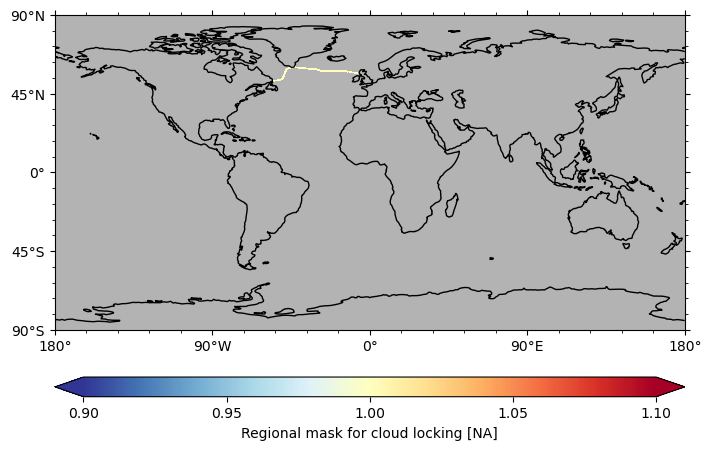

In [47]:
ds_osnap_mask_ocn = ds_mask_ocn["north_atlantic"].where(ocn_osnap_ind)
ds_osnap_mask_ocn.attrs["name"] = "Points near OSNAP line"
ds_osnap_mask_ocn.pyic.plot(
    fpath_tgrid=fpath_tgrid["ocn"],
    fpath_ckdtree=fpath_ckdtree["ocn"],
    land_facecolor="none",
    plot_method="tgrid",
)

In [49]:
# Output OSNAP points, densed OSNAP points, atmospheric and oceanic masks
np.savetxt(f"{output_dir}/osnap_points.txt", osnap_points)
np.savetxt(f"{output_dir}/osnap_points_densified.txt", osnap_points_densified)
ds_osnap_mask_atm.to_netcdf(f"{output_dir}/ds_osnap_mask_atm.nc")
ds_osnap_mask_ocn.to_netcdf(f"{output_dir}/ds_osnap_mask_ocn.nc")